# `2D_Vortex_JIT` — output analysis

Interactive analysis of a run written by `python -m vortex_jit` (`setup.h5` + `fields.h5`).

1. **View** — pressure & electrostatic potential side by side, frame by frame (slider).
2. **Modes** — poloidal-mode (m-number) amplitude spectrum on a circle `r = rho`, plus the
   linear growth rate `gamma = d ln|a_m|/dt` (auto-detected exponential phase).

Edit the **Parameters** cell, then Run All.

## Setup

In [70]:
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt
%matplotlib inline

### Parameters — edit these

In [ ]:
# --- run directory (must contain setup.h5 and fields.h5) ---
RUNDIR = "runs/cart_U0"          # <<< point at your run

# --- coordinate system ---
COORD  = "auto"               # "auto" (detect from setup.h5) | "cart" | "polar"

# --- mode-analysis settings ---
FIELD  = "phi"                # field to Fourier-analyse: "phi" | "pres" | "vort"
RHO    = 0.30                 # ring radius for the poloidal analysis (units of L0)
MMAX   = 8                    # highest poloidal mode number m
NTHETA = 256                  # azimuthal sample points (cart ring interp; polar uses native)
# growth-rate fit: soft amplitude bounds (fraction of peak) for the AUTO linear-window
# search -- LO skips the seed-noise floor, HI skips the saturation roll-over.  The window
# itself is found automatically (max R^2), so these rarely need tuning.
LO, HI = 0.0, 0.9

### Helper functions

In [97]:
def sample_ring(field2d, x, y, rho, ntheta):
    """Bilinear-interpolate a (ny,nx) field onto ntheta points on the circle
    r=rho (centre origin), with periodic wrap at the domain edges."""
    theta = np.arange(ntheta) * (2.0 * np.pi / ntheta)
    xs = rho * np.cos(theta); ys = rho * np.sin(theta)
    nx = x.size; ny = y.size
    dx = x[1] - x[0]; dy = y[1] - y[0]
    fi = (xs - x[0]) / dx; fj = (ys - y[0]) / dy
    i0 = np.floor(fi).astype(int); j0 = np.floor(fj).astype(int)
    ti = fi - i0; tj = fj - j0
    i0m = i0 % nx; i1m = (i0 + 1) % nx
    j0m = j0 % ny; j1m = (j0 + 1) % ny
    f = field2d
    return theta, (f[j0m, i0m] * (1 - ti) * (1 - tj) + f[j0m, i1m] * ti * (1 - tj)
                   + f[j1m, i0m] * (1 - ti) * tj + f[j1m, i1m] * ti * tj)

def mode_amplitudes(ring, mmax):
    """|a_m|, m=0..mmax (m>=1 folds the +/-m pair -> peak amplitude of that harmonic)."""
    N = ring.size
    amp = np.abs(np.fft.rfft(ring) / N)
    amp[1:] *= 2.0
    return amp[: mmax + 1]

def fit_growth(t, a, lo=0.0, hi=0.9, wmin=5):
    """Auto-detect the linear (exponential) growth phase and fit gamma = d ln a / dt.

    Scans EVERY contiguous sub-window (>= wmin points) of the RISING part of the
    signal whose amplitude lies in [lo, hi]*peak, and returns the window that
    maximises  R^2 * sqrt(length)  with positive slope -- i.e. the cleanest AND
    longest straight segment in log-space.  This replaces the old fixed-band fit,
    so no hand-tuning of a narrow [lo,hi] is needed; lo/hi are just soft bounds
    (lo skips the seed-noise floor, hi skips the saturation roll-over).

    Returns (gamma, t0, t1, r2, mask) where mask flags the chosen frames.
    """
    t = np.asarray(t, float); a = np.asarray(a, float)
    none = (np.nan, np.nan, np.nan, np.nan, np.zeros_like(a, bool))
    good = np.isfinite(a) & (a > 0)
    if good.sum() < wmin:
        return none
    amax = a[good].max(); imax = int(np.argmax(a))
    cand = good & (a >= lo * amax) & (a <= hi * amax)
    cand[imax + 1:] = False                              # rising part only
    ii = np.where(cand)[0]
    if ii.size < wmin:                                   # relax to the whole rise
        ii = np.where(good[:imax + 1])[0]
    if ii.size < wmin:
        return none
    ll = np.full_like(a, -np.inf); ll[good] = np.log(a[good])   # avoid log(0) warning
    best = (-np.inf, np.nan, np.nan, np.nan, np.nan, None)
    for p in range(ii.size - wmin + 1):
        for q in range(p + wmin - 1, ii.size):
            seg = ii[p:q + 1]; ts = t[seg]; ls = ll[seg]
            g, b = np.polyfit(ts, ls, 1)
            if g <= 0:
                continue
            pred = g * ts + b
            r2 = 1.0 - np.sum((ls - pred) ** 2) / max(np.sum((ls - ls.mean()) ** 2), 1e-30)
            score = r2 * np.sqrt(seg.size)               # clean AND long
            if score > best[0]:
                best = (score, g, ts[0], ts[-1], r2, seg)
    if best[5] is None:
        return none
    _, g, t0, t1, r2, seg = best
    mask = np.zeros_like(a, bool); mask[seg] = True
    return g, t0, t1, r2, mask

### Load data

In [98]:
# --- load, coordinate-aware.  cart: setup has x,y (1D) + fields (ny,nx).
#     polar: setup has r,theta (1D) + x,y (2D meshes) + fields (nr,ntheta),
#     tagged by the attribute coord_type="polar". ---
_setup = h5py.File(os.path.join(RUNDIR, "setup.h5"), "r")
attrs = dict(_setup.attrs)
COORD_EFF = (attrs.get("coord_type", "cart") if COORD == "auto" else COORD)
t_bar   = float(attrs.get("t_bar", 1.0))
P_bar   = float(attrs.get("P_bar", 1.0))
phi_bar = float(attrs.get("phi_bar", 1.0))

if COORD_EFF == "polar":
    r  = np.asarray(_setup["r"], float);  theta = np.asarray(_setup["theta"], float)
    X2 = np.asarray(_setup["x"], float);  Y2 = np.asarray(_setup["y"], float)   # (nr,ntheta)
    nr = r.size; rmax_dom = float(r.max())
    def ring_at(field2d, rho):
        """field on the circle r=rho: linear radial interp, native theta grid."""
        j = int(np.clip(np.searchsorted(r, rho), 1, nr - 1))
        w = (rho - r[j - 1]) / (r[j] - r[j - 1])
        return (1 - w) * field2d[j - 1] + w * field2d[j]
else:
    x = np.asarray(_setup["x"], float);  y = np.asarray(_setup["y"], float)
    rmax_dom = float(np.hypot(max(abs(x[0]), abs(x[-1])), max(abs(y[0]), abs(y[-1]))))
    def ring_at(field2d, rho):
        _, ring = sample_ring(field2d, x, y, rho, NTHETA); return ring
_setup.close()

def draw_field(ax, F, cmap, vmin, vmax):
    """imshow (cart) or closed-disk pcolormesh (polar); returns the mappable."""
    if COORD_EFF == "polar":
        Xc = np.concatenate([X2, X2[:, :1]], axis=1)      # close the theta seam
        Yc = np.concatenate([Y2, Y2[:, :1]], axis=1)
        Fc = np.concatenate([F,  F[:, :1]],  axis=1)
        im = ax.pcolormesh(Xc, Yc, Fc, cmap=cmap, vmin=vmin, vmax=vmax, shading="gouraud")
    else:
        im = ax.imshow(F, origin="lower", extent=[x.min(), x.max(), y.min(), y.max()],
                       cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_aspect("equal"); return im

fh = h5py.File(os.path.join(RUNDIR, "fields.h5"), "r")   # lazy reads
t  = np.asarray(fh["t"], float); nf = fh["phi"].shape[0]
print(f"coord = {COORD_EFF}   |   {nf} frames, t in [{t[0]:.3f}, {t[-1]:.3f}] t_bar "
      f"(t_bar={t_bar:.3e} s)")
print(f"field shape {tuple(fh['phi'].shape[1:])}   domain max radius ~ {rmax_dom:.3f} L0")

coord = cart   |   101 frames, t in [0.000, 50.000] t_bar (t_bar=3.440e-05 s)
field shape (512, 512)   domain max radius ~ 1.411 L0


## 1. View — pressure & potential side by side

Use the slider (needs `ipywidgets`); otherwise the fallback shows the last frame,
or set `FRAME` in the next cell.

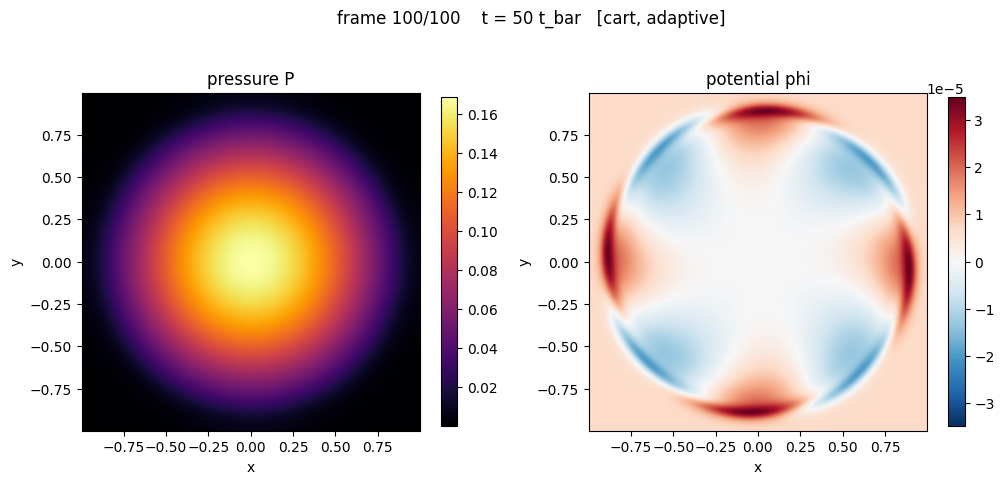

In [99]:
ADAPTIVE = True   # True: colour limits auto-scale to EACH frame (best for seeing the
                  # instability pattern early on); False: fixed limits across all frames.

# fixed limits (used only when ADAPTIVE = False), from first & last frames
_Pmax_fix = max(np.asarray(fh["pres"][0]).max(), np.asarray(fh["pres"][nf - 1]).max())
_Vm_fix   = max(np.abs(np.asarray(fh["phi"][0])).max(),
                np.abs(np.asarray(fh["phi"][nf - 1])).max()) or 1.0

def show_frame(i):
    i = int(np.clip(i, 0, nf - 1))
    P = np.asarray(fh["pres"][i]); V = np.asarray(fh["phi"][i])
    if ADAPTIVE:
        Pmin, Pmax = float(P.min()), float(P.max()); Vm = float(np.abs(V).max()) or 1.0
    else:
        Pmin, Pmax, Vm = 0.0, _Pmax_fix, _Vm_fix
    fig, (axP, axV) = plt.subplots(1, 2, figsize=(12, 5.2))
    imP = draw_field(axP, P, "inferno", Pmin, Pmax)     # imshow (cart) / pcolormesh (polar)
    imV = draw_field(axV, V, "RdBu_r", -Vm, Vm)
    axP.set_title("pressure P"); axV.set_title("potential phi")
    for ax in (axP, axV):
        ax.set_xlabel("x"); ax.set_ylabel("y")
    fig.colorbar(imP, ax=axP, shrink=0.82); fig.colorbar(imV, ax=axV, shrink=0.82)
    fig.suptitle(f"frame {i}/{nf - 1}    t = {t[i]:.4g} t_bar   "
                 f"[{COORD_EFF}, {'adaptive' if ADAPTIVE else 'fixed'}]"); plt.show()

# Fast, dependency-free render of one frame (change the index, e.g. 0, nf//2, nf-1):
show_frame(nf-1)

In [100]:
## --- OPTIONAL: interactive frame scrubber (needs the ipywidgets FRONT-END enabled) ---
## If this shows "loading" forever, the widget front-end isn't enabled: either run
##   pip install ipywidgets jupyterlab_widgets   (then restart kernel + refresh),
## or just skip this cell and use show_frame(i) / the montage below (no widgets needed).
#try:
#    from ipywidgets import interact, IntSlider
#    interact(show_frame, i=IntSlider(min=0, max=nf - 1, step=1, value=nf - 1,
#                                     continuous_update=False))   # redraw on release only
#except Exception as e:
#    print("ipywidgets unavailable:", e, "-> use show_frame(i) or the montage below.")

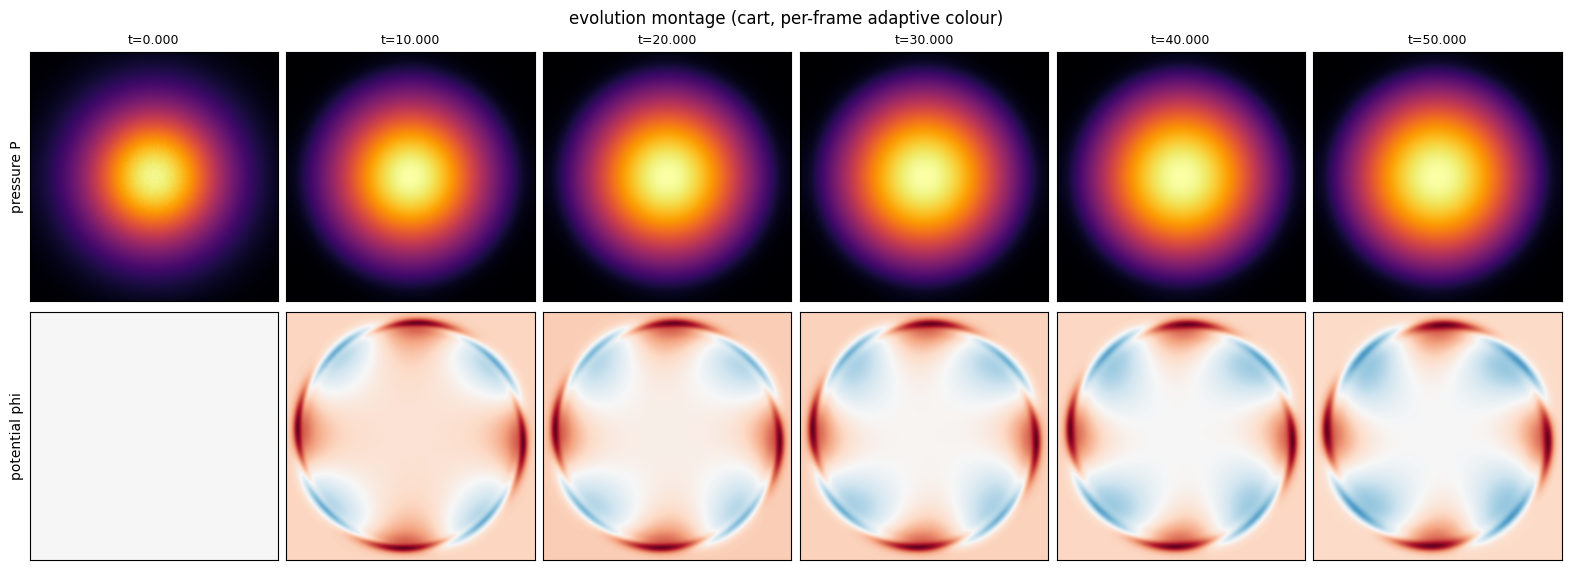

In [101]:
# --- Widget-free evolution montage: N frames across the run (per-frame adaptive) ---
# (needs the Load cell run first, which defines draw_field / COORD_EFF)
idxs = np.linspace(0, nf - 1, 6).astype(int)
fig, axes = plt.subplots(2, len(idxs), figsize=(2.6 * len(idxs), 5.6),
                         constrained_layout=True)          # robust w/ pcolormesh + equal aspect
for c, k in enumerate(idxs):
    P = np.asarray(fh["pres"][k]); V = np.asarray(fh["phi"][k])
    vm = float(np.abs(V).max()) or 1.0
    pmn, pmx = float(P.min()), float(P.max())
    if pmx <= pmn:                                          # guard constant field
        pmx = pmn + 1e-30
    draw_field(axes[0, c], P, "inferno", pmn, pmx)
    draw_field(axes[1, c], V, "RdBu_r", -vm, vm)
    axes[0, c].set_title(f"t={t[k]:.3f}", fontsize=9)
    for rr in (0, 1):
        axes[rr, c].set_xticks([]); axes[rr, c].set_yticks([])
axes[0, 0].set_ylabel("pressure P"); axes[1, 0].set_ylabel("potential phi")
fig.suptitle(f"evolution montage ({COORD_EFF}, per-frame adaptive colour)")
plt.show()

## 2. Poloidal-mode spectrum & linear growth rate

Samples `FIELD` on the circle `r = RHO`, Fourier-analyses in the azimuthal angle,
and fits the growth rate over the auto-detected exponential phase.

In [102]:
rho = RHO
if rho > rmax_dom:
    print(f"WARNING: RHO={rho} exceeds domain radius {rmax_dom:.3f}; clamping."); rho = 0.98 * rmax_dom

A = np.zeros((nf, MMAX + 1))                       # A[frame, m]
for k in range(nf):
    ring = ring_at(np.asarray(fh[FIELD][k]), rho)  # coord-aware (cart interp / polar native)
    A[k] = mode_amplitudes(ring, MMAX)
A_tot = np.sqrt(np.sum(A[:, 1:] ** 2, axis=1))     # non-axisymmetric RMS

g_tot, t0, t1, r2, band = fit_growth(t, A_tot, LO, HI)
print(f"=== field={FIELD}  rho={rho:.3f} L0  coord={COORD_EFF}  ({nf} frames) ===")
print(f"{'m':>3} {'|a_m| final':>13} {'gamma[1/tbar]':>14} {'gamma[1/s]':>12} {'R^2':>6}")
dom_m, dom_g = 0, -np.inf
for m in range(1, MMAX + 1):
    gm, _a, _b, r2m, _msk = fit_growth(t, A[:, m], LO, HI)
    print(f"{m:>3} {A[-1, m]:>13.3e} {gm:>14.4f} {gm / t_bar:>12.3e} {r2m:>6.3f}")
    if np.isfinite(gm) and A[-1, m] > 1e-30 and gm > dom_g:
        dom_m, dom_g = m, gm
print("-" * 52)
print(f"TOTAL non-axisym RMS: gamma = {g_tot:.4f}/t_bar = {g_tot / t_bar:.3e}/s  "
      f"(linear phase t in [{t0:.3f},{t1:.3f}], R^2={r2:.3f})")
if np.isfinite(g_tot) and g_tot > 0:
    print(f"                      e-folding tau = {1 / g_tot:.3f} t_bar = {t_bar / g_tot:.3e} s")
fin = A[-1, 1:]
print(f"dominant mode (last frame): m={int(np.argmax(fin)) + 1} (|a|={fin.max():.3e}); "
      f"fastest-growing: m={dom_m} (gamma={dom_g:.4f}/t_bar)")

=== field=phi  rho=0.300 L0  coord=cart  (101 frames) ===
  m   |a_m| final  gamma[1/tbar]   gamma[1/s]    R^2
  1     8.339e-08            nan          nan    nan
  2     1.338e-08            nan          nan    nan
  3     1.004e-09            nan          nan    nan
  4     5.467e-07         0.0487    1.415e+03  0.924
  5     2.988e-12            nan          nan    nan
  6     1.167e-11            nan          nan    nan
  7     3.930e-13            nan          nan    nan
  8     1.070e-09            nan          nan    nan
----------------------------------------------------
TOTAL non-axisym RMS: gamma = 0.0352/t_bar = 1.024e+03/s  (linear phase t in [1.000,24.000], R^2=0.973)
                      e-folding tau = 28.378 t_bar = 9.762e-04 s
dominant mode (last frame): m=4 (|a|=5.467e-07); fastest-growing: m=4 (gamma=0.0487/t_bar)


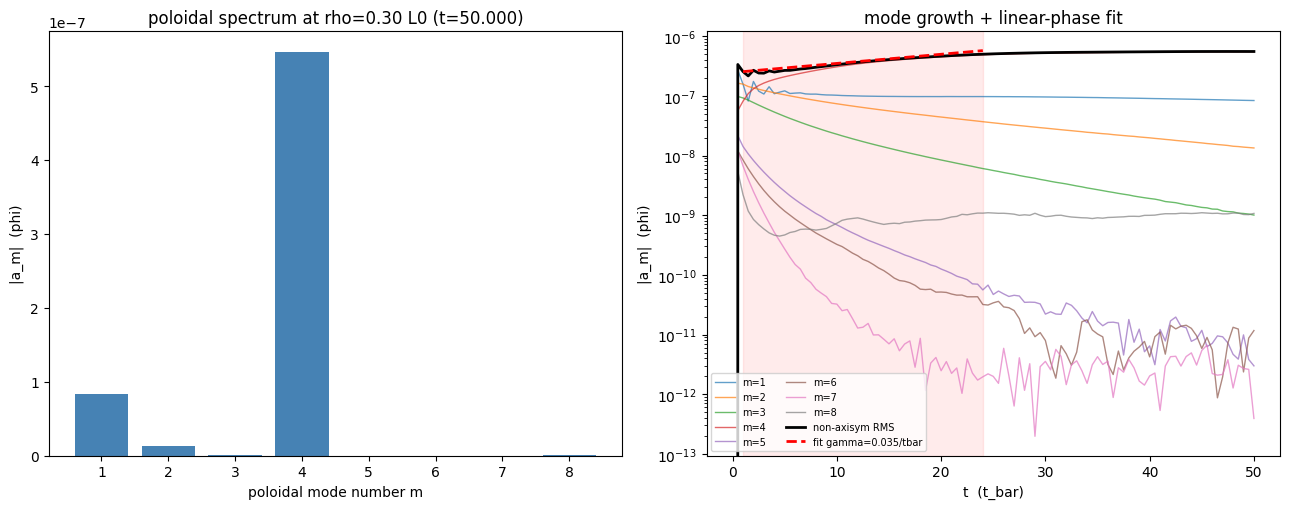

In [103]:
fig, (axS, axG) = plt.subplots(1, 2, figsize=(13, 5.2))
ms = np.arange(MMAX + 1)
axS.bar(ms[1:], A[-1, 1:], color="steelblue")
axS.set_xlabel("poloidal mode number m"); axS.set_ylabel(f"|a_m|  ({FIELD})")
axS.set_title(f"poloidal spectrum at rho={rho:.2f} L0 (t={t[-1]:.3f})")
for m in range(1, MMAX + 1):
    axG.semilogy(t, A[:, m], lw=1, alpha=0.7, label=f"m={m}")
axG.semilogy(t, A_tot, "k-", lw=2, label="non-axisym RMS")
if np.isfinite(g_tot):
    tf = t[band]
    axG.semilogy(tf, A_tot[band][0] * np.exp(g_tot * (tf - tf[0])), "r--", lw=2,
                 label=f"fit gamma={g_tot:.3f}/tbar")
    axG.axvspan(t0, t1, color="red", alpha=0.08)
axG.set_xlabel("t  (t_bar)"); axG.set_ylabel(f"|a_m|  ({FIELD})")
axG.set_title("mode growth + linear-phase fit"); axG.legend(fontsize=7, ncol=2)
fig.tight_layout(); plt.show()

## 3. Growth-rate spectrum — γ(m) vs poloidal mode number

The **interchange dispersion**: per-mode linear growth rate `γ_m` versus `m`. Without
FLR (`U=0`) γ increases with m (no short-wavelength cutoff → broadband); with FLR
(`U<0`) the high-m modes are stabilized and a single low-m mode dominates.

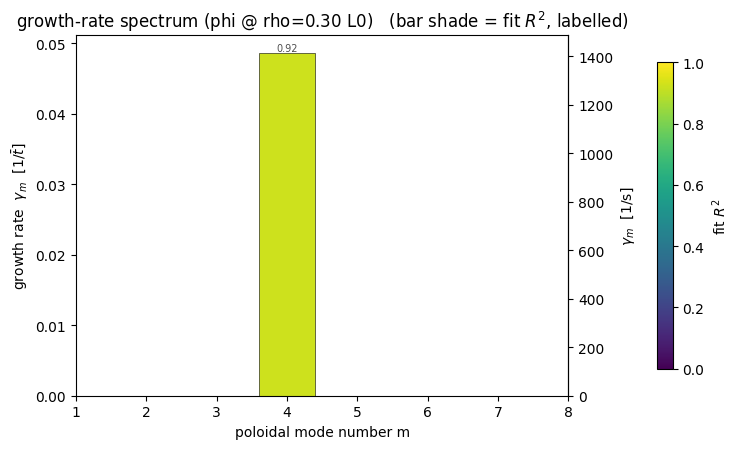

fastest-growing well-fit mode: m=4  gamma=0.049/t_bar = 1.415e+03/s  (R^2=0.92)


In [104]:
def growth_rate_spectrum(A, t, lo=LO, hi=HI):
    """Per-mode linear growth rate gamma_m, fit R^2, and the auto-detected fit
    time window [t0_m, t1_m] (+ boolean frame-mask) for m=1..MMAX."""
    mmax = A.shape[1] - 1
    gm = np.full(mmax + 1, np.nan); r2m = np.full(mmax + 1, np.nan)
    t0m = np.full(mmax + 1, np.nan); t1m = np.full(mmax + 1, np.nan)
    masks = [np.zeros(A.shape[0], bool) for _ in range(mmax + 1)]
    for m in range(1, mmax + 1):
        g, t0, t1, r2, mask = fit_growth(t, A[:, m], lo, hi)
        gm[m], r2m[m], t0m[m], t1m[m] = g, r2, t0, t1
        masks[m] = mask
    return gm, r2m, t0m, t1m, masks

def plot_growth_vs_m(A, t, t_bar, lo=LO, hi=HI, field=FIELD, rho=None):
    """Bar plot of gamma_m vs poloidal mode m, shaded by fit R^2; right axis in 1/s."""
    gm, r2m, *_ = growth_rate_spectrum(A, t, lo, hi)
    ms = np.arange(1, A.shape[1]); g = gm[1:]; r2 = np.nan_to_num(r2m[1:])
    fig, ax = plt.subplots(figsize=(7.8, 4.6))
    ax.bar(ms, g, color=plt.cm.viridis(np.clip(r2, 0, 1)), edgecolor="k", lw=0.4)
    for mi, gi, ri in zip(ms, g, r2):
        if np.isfinite(gi):
            ax.annotate(f"{ri:.2f}", (mi, gi), ha="center",
                        va="bottom" if gi >= 0 else "top", fontsize=7, color="0.3")
    ax.axhline(0, color="k", lw=0.6)
    ax.set_xlabel("poloidal mode number m"); ax.set_xticks(ms)
    ax.set_ylabel(r"growth rate  $\gamma_m$  [1/$\bar t$]")
    ttl = f"growth-rate spectrum ({field}" + (f" @ rho={rho:.2f} L0" if rho else "") + ")"
    ax.set_title(ttl + "   (bar shade = fit $R^2$, labelled)")
    ax.secondary_yaxis("right", functions=(lambda v: v / t_bar, lambda v: v * t_bar)
                       ).set_ylabel(r"$\gamma_m$  [1/s]")
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(0, 1)); sm.set_array([])
    fig.colorbar(sm, ax=ax, label="fit $R^2$", pad=0.13, shrink=0.85)
    fig.tight_layout(); plt.show()
    return gm, r2m

# A, t, rho come from section 2; run that first.
gm, r2m = plot_growth_vs_m(A, t, t_bar, rho=rho)
best = int(np.nanargmax(np.where(np.nan_to_num(r2m) > 0.5, gm, np.nan))) \
    if np.any(np.nan_to_num(r2m) > 0.5) else int(np.nanargmax(gm))
print(f"fastest-growing well-fit mode: m={best}  gamma={gm[best]:.3f}/t_bar "
      f"= {gm[best]/t_bar:.3e}/s  (R^2={r2m[best]:.2f})")

## 4. Which time window was each mode fit over?

For a **broadband (U=0)** case many modes grow at similar rates, and the auto-detector
can land on a *different* time window for each `m` — so comparing a single `gamma_m`
between runs (e.g. cart vs polar) can mislead. This diagnostic shows, per mode, the
`|a_m(t)|` curve with its fitted window **bold**, plus a timeline of `[t0_m, t1_m]`
coloured by `gamma_m`. If the windows differ a lot between runs, the `gamma_m`
comparison isn't apples-to-apples — pin a common window with `LO`/`HI` (or compare the
total non-axisym RMS, which is more robust).

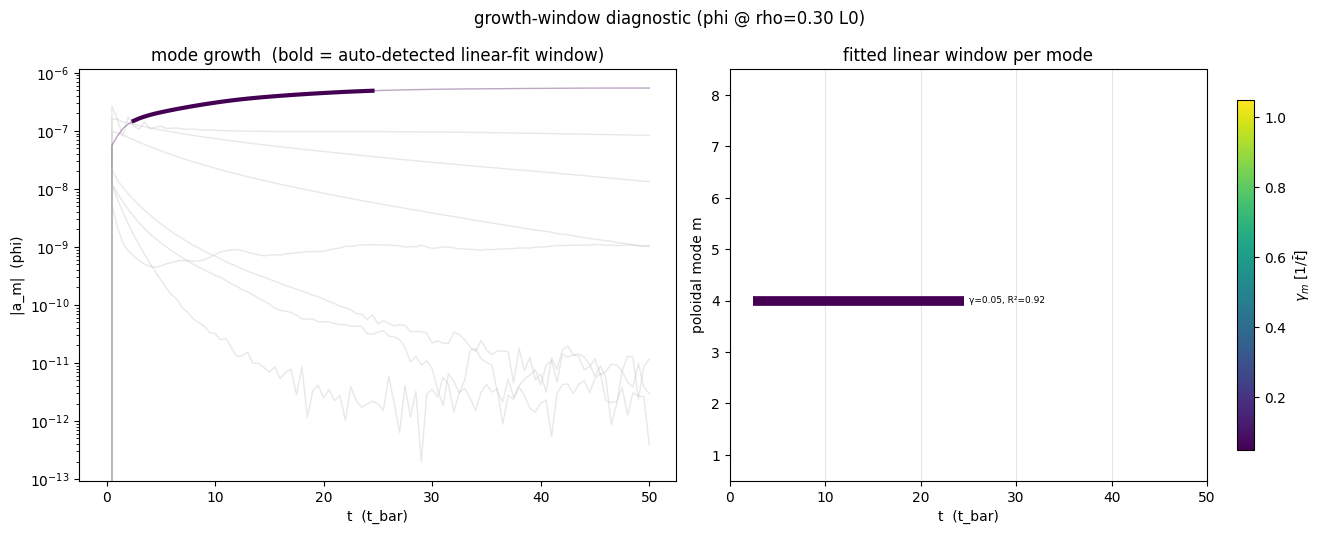

  m  gamma[1/tb]    R^2      t0      t1      Δt  #pts
  1          nan    nan     nan     nan     nan     0
  2          nan    nan     nan     nan     nan     0
  3          nan    nan     nan     nan     nan     0
  4        0.049   0.92   2.500  24.500  22.000    45
  5          nan    nan     nan     nan     nan     0
  6          nan    nan     nan     nan     nan     0
  7          nan    nan     nan     nan     nan     0
  8          nan    nan     nan     nan     nan     0


(array([      nan,       nan,       nan,       nan, 0.0486622,       nan,
              nan,       nan,       nan]),
 array([       nan,        nan,        nan,        nan, 0.92364478,
               nan,        nan,        nan,        nan]),
 array([nan, nan, nan, nan, 2.5, nan, nan, nan, nan]),
 array([ nan,  nan,  nan,  nan, 24.5,  nan,  nan,  nan,  nan]))

In [105]:
def plot_growth_windows(A, t, t_bar, lo=LO, hi=HI, field=FIELD, rho=None):
    """Show WHICH time window each poloidal mode's growth rate was fit over.
    Left: |a_m(t)| for each m (bold = the auto-detected fit window).
    Right: a timeline of [t0_m, t1_m] per mode, coloured by gamma_m (labelled)."""
    gm, r2m, t0m, t1m, masks = growth_rate_spectrum(A, t, lo, hi)
    mmax = A.shape[1] - 1; ms = np.arange(1, mmax + 1)
    fin = np.isfinite(gm[1:])
    g0 = float(np.nanmin(gm[1:])) if fin.any() else 0.0
    g1 = float(np.nanmax(gm[1:])) if fin.any() else 1.0
    if g1 <= g0:
        g1 = g0 + 1.0
    cmap = plt.cm.viridis; norm = plt.Normalize(g0, g1)

    fig, (axL, axR) = plt.subplots(1, 2, figsize=(13.5, 5.4))
    for m in ms:
        col = cmap(norm(gm[m])) if np.isfinite(gm[m]) else "0.75"
        axL.semilogy(t, A[:, m], color=col, lw=1, alpha=0.35)
        mk = masks[m]
        if mk is not None and mk.any():
            axL.semilogy(t[mk], A[mk, m], color=col, lw=3)       # fitted window (bold)
    axL.set_xlabel("t  (t_bar)"); axL.set_ylabel(f"|a_m|  ({field})")
    axL.set_title("mode growth  (bold = auto-detected linear-fit window)")

    for m in ms:
        if np.isfinite(t0m[m]):
            axR.plot([t0m[m], t1m[m]], [m, m], lw=7, solid_capstyle="butt",
                     color=cmap(norm(gm[m])))
            axR.annotate(f"γ={gm[m]:.2f}, R²={r2m[m]:.2f}", (t1m[m], m),
                         xytext=(4, 0), textcoords="offset points", fontsize=6.5, va="center")
    axR.set_xlabel("t  (t_bar)"); axR.set_ylabel("poloidal mode m")
    axR.set_yticks(ms); axR.set_ylim(0.5, mmax + 0.5); axR.set_xlim(t[0], t[-1])
    axR.grid(axis="x", alpha=0.3); axR.set_title("fitted linear window per mode")
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
    fig.colorbar(sm, ax=axR, label=r"$\gamma_m$ [1/$\bar t$]", shrink=0.85)
    ttl = f"growth-window diagnostic ({field}" + (f" @ rho={rho:.2f} L0" if rho else "") + ")"
    fig.suptitle(ttl); fig.tight_layout(); plt.show()

    print(f"{'m':>3} {'gamma[1/tb]':>12} {'R^2':>6} {'t0':>7} {'t1':>7} {'Δt':>7} {'#pts':>5}")
    for m in ms:
        n = int(masks[m].sum())
        dtw = (t1m[m] - t0m[m]) if np.isfinite(t0m[m]) else np.nan
        print(f"{m:>3} {gm[m]:>12.3f} {r2m[m]:>6.2f} {t0m[m]:>7.3f} {t1m[m]:>7.3f} {dtw:>7.3f} {n:>5}")
    return gm, r2m, t0m, t1m

plot_growth_windows(A, t, t_bar, rho=rho)